In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})

def mm(cc, cx, xx, fx=0.1):
    return (1-fx)**2 *cc+fx*(1-fx)*cx+fx**2 * xx

In [3]:
ma=27

kref=8.4e12 * pow(pow(10,-ma)/0.67,1/2) * 0.666**0.25

k, dcdc22, dcdc22_EdS, dcTc22, dcTc22_EdS, dcdx22, dcdx22_EdS, dcTx22, dcTx22_EdS, dxdx22, dxdx22_EdS, PL_cc, TL_x =np.loadtxt(f'/home/fverdian/class/soundspeed-scripts/numerical-integrals/quantumpressure/P22-wqp-NOQPtest_3points_ma27p0-fx0p1-N5000-p2.txt', unpack=True)[:,:70]
k, dcdc13, dcdc13_EdS, dcTc13, dcTc13_EdS, dcdx13, dcdx13_EdS, dcTx13, dcTx13_EdS, dxdx13, dxdx13_EdS, PL_cc, TL_x, dcdx_IR  =np.loadtxt(f'/home/fverdian/class/soundspeed-scripts/numerical-integrals/quantumpressure/P13-wqp-NOQPtest_3points_ma27p0-fx0p1-N5000-p2.txt', unpack=True)[:,:70]

k_wqp, dcdc22_wqp, dcdc22_wqp_EdS, dcTc22_wqp, dcTc22_wqp_EdS, dcdx22_wqp, dcdx22_wqp_EdS, dcTx22_wqp, dcTx22_wqp_EdS, dxdx22_wqp, _, _, _ =np.loadtxt(f'/home/fverdian/class/soundspeed-scripts/numerical-integrals/quantumpressure/P22-wqp_3points_ma27p0-fx0p1-N5000-p2.txt', unpack=True)[:,:70]
k_wqp, dcdc13_wqp, dcdc13_wqp_EdS, dcTc13_wqp, _, dcdx13_wqp, dcdx13_wqp_EdS, dcTx13_wqp, _, dxdx13_wqp, _, PL_cc_wqp, TL_x_wqp ,_=np.loadtxt(f'/home/fverdian/class/soundspeed-scripts/numerical-integrals/quantumpressure/P13-wqp_3points_ma27p0-fx0p1-N5000-p2.txt', unpack=True)[:,:70]



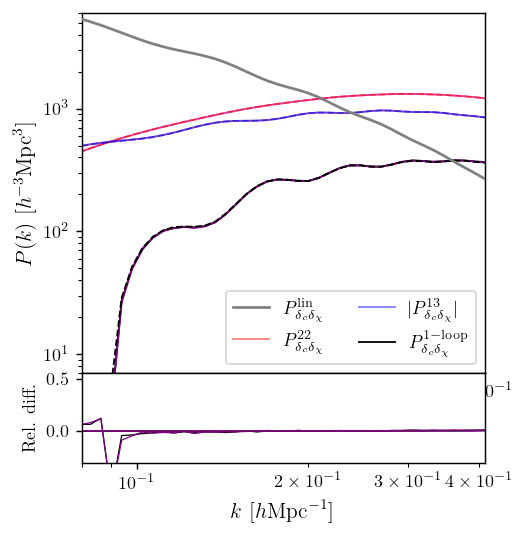

In [5]:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 4.5), dpi=130, gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.0})

# Upper panel
ax1.plot(k, PL_cc*TL_x, 'gray', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_c\delta_\chi}$', zorder=4)
ax1.plot(k, dcdx22, 'r', label=r'$P^{22}_{\delta_c\delta_\chi}$', linewidth=1, alpha=0.5)

ax1.plot(k_wqp, dcdx22_wqp, 'm', linewidth=1, alpha=0.5)

ax1.plot(k, dcdx22_EdS, 'r--', linewidth=1, alpha=0.5)
ax1.plot(k, -dcdx13, 'b', label=r'$|P^{13}_{\delta_c\delta_\chi}|$', linewidth=1, alpha=0.5)
ax1.plot(k_wqp, -dcdx13_wqp, 'purple', linewidth=1, alpha=0.5)

ax1.plot(k, -dcdx13_EdS, 'b--', linewidth=1, alpha=0.5)
ax1.plot(k, (dcdx22+dcdx13), 'k', label=r'$P^{\mathrm{1-loop}}_{\delta_c\delta_\chi}$', linewidth=1)
ax1.plot(k_wqp, (dcdx22_wqp+dcdx13_wqp), 'purple', linewidth=1)

ax1.plot(k, (dcdx22_EdS+dcdx13_EdS), 'k--', linewidth=1)
ax1.axhline(y=0., linestyle=':', color='k', linewidth=0.3)
ax1.set_xscale('log')
ax1.set_yscale('log')

ax1.set_ylim([7, 6000])
# ax1.set_ylim([-300, 300])

ax1.legend(fontsize=10, loc='best', ncol=2)
ax1.set_ylabel(r'$P(k)$ $[h^{-3}\mathrm{Mpc}^{3}]$', fontsize=12)
ax1.tick_params(axis='x', labelbottom=False)

relative_diff_1l_total = ((dcdx22 + dcdx13) - (dcdx22_EdS + dcdx13_EdS)) / (dcdx22 + dcdx13)
ax2.plot(k, relative_diff_1l_total, 'k', linewidth=0.7, linestyle='-')

relative_diff_1l_total_wqp = ((dcdx22_wqp + dcdx13_wqp) - (dcdx22_wqp_EdS + dcdx13_wqp_EdS)) / (dcdx22_wqp + dcdx13_wqp)
ax2.plot(k_wqp, relative_diff_1l_total_wqp, 'purple', linewidth=0.7, linestyle='-')

relative_diff_Ptot_total = (((dcdx22 + dcdx13)) - ( dcdx22_EdS + dcdx13_EdS))/(PL_cc*TL_x + (dcdx22 + dcdx13))
ax2.plot(k, relative_diff_Ptot_total, 'gray', linewidth=1., linestyle='-')

relative_diff_Ptot_total_wqp = (((dcdx22_wqp + dcdx13_wqp)) - ( dcdx22_wqp_EdS + dcdx13_wqp_EdS))/(PL_cc_wqp*TL_x_wqp + (dcdx22_wqp + dcdx13_wqp))
ax2.plot(k_wqp, relative_diff_Ptot_total_wqp, 'purple', linewidth=1., linestyle='-')



ax2.axhline(y=0., linestyle=':', color='k', linewidth=0.3)
# ax2.axvline(x=kref, linestyle=':', color='k', linewidth=0.3)
# ax1.axvline(x=kref, linestyle=':', color='k', linewidth=0.3)

ax2.set_ylim([-0.31,0.55])
ax2.set_xscale('log')
ax2.set_xlabel(r'$k$ $[h\mathrm{Mpc}^{-1}]$', fontsize=12)
ax2.set_ylabel('Rel. diff.', fontsize=10)


# ax1.set_title(r'$m_a=10^{-'+str(ma)+r'}\,\mathrm{eV}$, $p=2$')
ax1.set_xlim([0.08, 0.41])
ax2.set_xlim([0.08, 0.41])

# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/1loop_num_dcdchi.pdf', bbox_inches='tight')

plt.show()

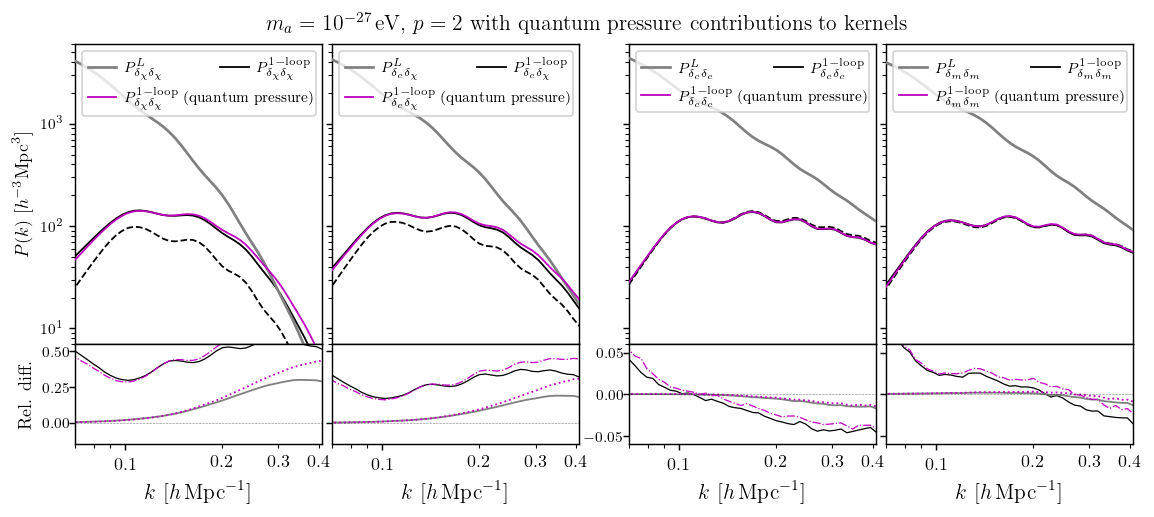

In [5]:
import matplotlib.ticker as ticker

fig, axs = plt.subplots(2, 5, figsize=(10.5, 4.), dpi=130, gridspec_kw={'height_ratios': [3, 1],'width_ratios': [1,1,0.12,1, 1], 'hspace': 0.0, 'wspace':0.05},)

# ------ delta_chi delta_chi
ax = axs[0,0]
ax.plot(k, PL_cc*TL_x*TL_x, 'gray', linewidth=1.5, label='$P^{L}_{\delta_\chi\delta_\chi}$', zorder=4)
ax.plot(k, (dxdx22_wqp+dxdx13_wqp), 'm', label=r'$P^{\mathrm{1-loop}}_{\delta_\chi\delta_\chi}$  (quantum pressure)', linewidth=1,  zorder=10)
ax.plot(k, (dxdx22+dxdx13), 'k', label=r'$P^{\mathrm{1-loop}}_{\delta_\chi\delta_\chi}$', linewidth=1)
ax.plot(k, (dxdx22_EdS+dxdx13_EdS), 'k--', linewidth=1)

ax.set_ylabel(r'$P(k)$ $[h^{-3}\mathrm{Mpc}^{3}]$', fontsize=10)
# Lower panel (relative differences)
ax = axs[1,0]
relative_diff_1l_total = ((dxdx22 + dxdx13) - (dxdx22_EdS + dxdx13_EdS)) / (dxdx22 + dxdx13)
ax.plot(k, relative_diff_1l_total, 'k', linewidth=0.7, linestyle='-')
relative_diff_Ptot_total = ((dxdx22 + dxdx13) - (dxdx22_EdS + dxdx13_EdS)) / (PL_cc*TL_x*TL_x+ dxdx22 + dxdx13)
ax.plot(k, relative_diff_Ptot_total, 'gray', linewidth=1., linestyle='-')

relative_diff_1l_total = ((dxdx22_wqp + dxdx13_wqp) - (dxdx22_EdS + dxdx13_EdS)) / (dxdx22_wqp + dxdx13_wqp)
ax.plot(k, relative_diff_1l_total, 'm', linewidth=0.7, linestyle='-.')
relative_diff_Ptot_total = ((dxdx22_wqp + dxdx13_wqp) - (dxdx22_EdS + dxdx13_EdS)) / (PL_cc*TL_x*TL_x+ dxdx22_wqp + dxdx13_wqp)
ax.plot(k, relative_diff_Ptot_total, 'm', linewidth=1., linestyle=':')

ax.set_ylabel('Rel. diff.', fontsize=10)

# ------ delta_c delta_chi
ax = axs[0,1]
ax.plot(k, PL_cc*TL_x, 'gray', linewidth=1.5, label='$P^{L}_{\delta_c\delta_\chi}$', zorder=4)
ax.plot(k, (dcdx22_wqp+dcdx13_wqp), 'm', label=r'$P^{\mathrm{1-loop}}_{\delta_c\delta_\chi}$  (quantum pressure)', linewidth=1, zorder=10)
ax.plot(k, (dcdx22+dcdx13), 'k', label=r'$P^{\mathrm{1-loop}}_{\delta_c\delta_\chi}$', linewidth=1)
ax.plot(k, (dcdx22_EdS+dcdx13_EdS), 'k--', linewidth=1)

# Lower panel (relative differences)
ax = axs[1,1]
relative_diff_1l_total = ((dcdx22 + dcdx13) - (dcdx22_EdS + dcdx13_EdS)) / (dcdx22 + dcdx13)
ax.plot(k, relative_diff_1l_total, 'k', linewidth=0.7, linestyle='-')
relative_diff_Ptot_total = (PL_cc*TL_x+ (dcdx22 + dcdx13)) / (PL_cc*TL_x+ dcdx22_EdS + dcdx13_EdS)-1
ax.plot(k, relative_diff_Ptot_total, 'gray', linewidth=1., linestyle='-')

relative_diff_1l_total = ((dcdx22_wqp + dcdx13_wqp) - (dcdx22_EdS + dcdx13_EdS)) / (dcdx22_wqp + dcdx13_wqp)
ax.plot(k, relative_diff_1l_total, 'm', linewidth=0.7, linestyle='-.')
relative_diff_Ptot_total = (PL_cc*TL_x+ (dcdx22_wqp + dcdx13_wqp)) / (PL_cc*TL_x+ dcdx22_EdS + dcdx13_EdS)-1
ax.plot(k, relative_diff_Ptot_total, 'm', linewidth=1., linestyle=':')


# ------ delta_c delta_c
ax = axs[0,3]
ax.plot(k, PL_cc, 'gray', linewidth=1.5, label='$P^{L}_{\delta_c\delta_c}$', zorder=4)
ax.plot(k, (dcdc22_wqp+dcdc13_wqp), 'm', label=r'$P^{\mathrm{1-loop}}_{\delta_c\delta_c}$  (quantum pressure)', linewidth=1, zorder=10)
ax.plot(k, (dcdc22+dcdc13), 'k', label=r'$P^{\mathrm{1-loop}}_{\delta_c\delta_c}$', linewidth=1)
ax.plot(k, (dcdc22_EdS+dcdc13_EdS), 'k--', linewidth=1)

# Lower panel (relative differences)
ax = axs[1,3]
relative_diff_1l_total = ((dcdc22 + dcdc13) - (dcdc22_EdS + dcdc13_EdS)) / (dcdc22 + dcdc13)
ax.plot(k, relative_diff_1l_total, 'k', linewidth=0.7, linestyle='-')
relative_diff_Ptot_total = ((dcdc22 + dcdc13) - (dcdc22_EdS + dcdc13_EdS)) / (PL_cc+ dcdc22 + dcdc13)
ax.plot(k, relative_diff_Ptot_total, 'gray', linewidth=1., linestyle='-')

relative_diff_1l_total = ((dcdc22_wqp + dcdc13_wqp) - (dcdc22_wqp_EdS + dcdc13_wqp_EdS)) / (dcdc22_wqp + dcdc13_wqp)
ax.plot(k, relative_diff_1l_total, 'm', linewidth=0.7, linestyle='-.')
relative_diff_Ptot_total = ((dcdc22_wqp + dcdc13_wqp) - (dcdc22_EdS + dcdc13_EdS)) / (PL_cc+ dcdc22_wqp + dcdc13_wqp)
ax.plot(k, relative_diff_Ptot_total, 'm', linewidth=1., linestyle=':')


# ------ delta_m delta_m
ax = axs[0,4]
ax.plot(k, PL_cc*mm(1,TL_x, TL_x**2), 'gray', linewidth=1.5, label='$P^{L}_{\delta_m\delta_m}$', zorder=4)
ax.plot(k, mm(dcdc22_wqp+dcdc13_EdS,dcdx22_wqp+dcdx13_wqp,dxdx22_wqp+dxdx13_wqp), 'm', label=r'$P^{\mathrm{1-loop}}_{\delta_m\delta_m}$ (quantum pressure)', linewidth=1, zorder=10)
ax.plot(k, mm(dcdc22+dcdc13,dcdx22+dcdx13,dxdx22+dxdx13), 'k', label=r'$P^{\mathrm{1-loop}}_{\delta_m\delta_m}$', linewidth=1)
ax.plot(k, mm(dcdc22_EdS+dcdc13_EdS,dcdx22_EdS+dcdx13_EdS,dxdx22_EdS+dxdx13_EdS), 'k--', linewidth=1)

# Lower panel (relative differences)
ax = axs[1,4]
relative_diff_1l_total = 1-mm(dcdc22_EdS+dcdc13_EdS,dcdx22_EdS+dcdx13_EdS,dxdx22_EdS+dxdx13_EdS)/mm(dcdc22+dcdc13,dcdx22+dcdx13,dxdx22+dxdx13)
ax.plot(k, relative_diff_1l_total, 'k', linewidth=0.7, linestyle='-')
relative_diff_Ptot_total = ( mm(dcdc22+dcdc13,dcdx22+dcdx13,dxdx22+dxdx13)-mm(dcdc22_EdS+dcdc13_EdS,dcdx22_EdS+dcdx13_EdS,dxdx22_EdS+dxdx13_EdS))/ (PL_cc*mm(1,TL_x, TL_x**2)+mm(dcdc22+dcdc13,dcdx22+dcdx13,dxdx22+dxdx13))
ax.plot(k, relative_diff_Ptot_total, 'gray', linewidth=1., linestyle='-')

relative_diff_1l_total = 1-mm(dcdc22_EdS+dcdc13_EdS,dcdx22_EdS+dcdx13_EdS,dxdx22_EdS+dxdx13_EdS)/mm(dcdc22_wqp+dcdc13_wqp,dcdx22_wqp+dcdx13_wqp,dxdx22_wqp+dxdx13_wqp)
ax.plot(k, relative_diff_1l_total, 'm', linewidth=0.7, linestyle='-.')
relative_diff_Ptot_total = ( mm(dcdc22_wqp+dcdc13_wqp,dcdx22_wqp+dcdx13_wqp,dxdx22_wqp+dxdx13_wqp)-mm(dcdc22_EdS+dcdc13_EdS,dcdx22_EdS+dcdx13_EdS,dxdx22_EdS+dxdx13_EdS))/ (PL_cc*mm(1,TL_x, TL_x**2)+mm(dcdc22_wqp+dcdc13_wqp,dcdx22_wqp+dcdx13_wqp,dxdx22_wqp+dxdx13_wqp))
ax.plot(k, relative_diff_Ptot_total, 'm', linewidth=1., linestyle=':')


for ax in axs.flat:
    ax.set_xscale('log')
    ax.set_xlim([0.07,0.41])
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:g}"))
    ax.xaxis.set_minor_formatter(ticker.FuncFormatter(lambda x, _: f"{x:g}" if x>0.09 else ""))

for i in [0,1,3,4]:
    axs[0,i].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    axs[0,i].legend(fontsize=8, loc='upper center', ncol=2, columnspacing=-6.5, handletextpad=0.5)
    axs[0,i].set_ylim([7e0,6.e3])
    axs[0,i].set_yscale('log')
    axs[1,i].axhline(y=0., linestyle=':', color='k', linewidth=0.3)
    axs[1,i].set_xlabel(r'$k$ $[h\,\mathrm{Mpc}^{-1}]$', fontsize=12)

for i in [0,1]:
    axs[1,i].set_ylim([-0.15,0.55])
for i in [3,4]:
    axs[1,i].set_ylim([-0.06,0.06])

for com in [(0,1),(1,1),(0,4),(1,4),(0,3)]:
    axs[com].tick_params(axis='y', labelleft=False)
axs[0, 2].axis('off')  # Turn off the top blank subplot
axs[1, 2].axis('off')  # Turn off the bottom blank subplot

axs[0,0].tick_params(axis='y',labelsize=8)  # Y-axis tick labels inside
axs[1,0].tick_params(axis='y',labelsize=8, pad=-0.1)  # Y-axis tick labels inside
axs[1,3].tick_params(axis='y',labelsize=8, pad=-0.1,)  # Y-axis tick labels inside

fig.text(0.5, 0.92, r'$m_a=10^{-'+str(ma)+r'}\,\mathrm{eV}$, $p=2$ with quantum pressure contributions to kernels', ha='center', va='center', fontsize=12)
plt.savefig('/home/fverdian/class/soundspeed-scripts/numerical-integrals/quantumpressure/1loop_m27_full_QP.pdf', bbox_inches='tight')

plt.show()